# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [47]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [48]:
# Load data
data = pd.read_csv('data/bcn_noise_ml_dataset.csv')
print(data)

                       road_id  noise_day  noise_evening  noise_night  \
0      13845167536_847716886_0         55             55           50   
1          21638869_30343583_0         55             50           50   
2         21638869_242318729_0         55             55           50   
3          21638869_30343672_0         60             60           55   
4       3055187877_431100338_0         60             60           55   
...                        ...        ...            ...          ...   
11664  2239783361_4577282718_0         60             60           55   
11665   2239783361_885307899_0         60             60           55   
11666   885307964_4577282718_0         60             60           55   
11667    885307964_885307899_0         60             60           55   
11668    885307899_885307964_0         60             60           55   

       road_length  road_category  dist_to_main  signals  transport   pois  \
0          401.484              5       258.6

In [49]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11669 entries, 0 to 11668
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          11669 non-null  str    
 1   noise_day        11669 non-null  int64  
 2   noise_evening    11669 non-null  int64  
 3   noise_night      11669 non-null  int64  
 4   road_length      11669 non-null  float64
 5   road_category    11669 non-null  int64  
 6   dist_to_main     11669 non-null  float64
 7   signals          11669 non-null  float64
 8   transport        11669 non-null  float64
 9   pois             11669 non-null  float64
 10  width            11669 non-null  float64
 11  height           11669 non-null  float64
 12  betw_centrality  11669 non-null  float64
 13  clos_centrality  11669 non-null  float64
 14  green_100        11669 non-null  float64
dtypes: float64(10), int64(4), str(1)
memory usage: 1.3 MB


## Predicting the Nomad Score


Prepare data

In [50]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) # keep only features
X

,road_length,road_category,dist_to_main,signals,transport,pois,width,height,betw_centrality,clos_centrality,green_100
0,401.484,5,258.681,0.249,2.491,0.747,22.219,11.196,0.004,0.000,4.347
1,90.290,5,429.190,1.106,3.319,33.185,6.331,10.125,0.000,0.000,0.000
2,15.056,4,512.334,6.655,19.965,50.000,18.019,10.500,0.001,0.000,0.000
3,15.405,4,516.423,6.504,19.512,50.000,16.833,12.000,0.002,0.000,0.000
4,46.142,5,214.042,2.170,4.340,2.170,20.818,8.625,0.007,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
11664,30.915,5,1013.939,16.187,9.712,6.475,0.000,0.000,0.000,0.000,13.061
11665,111.793,5,1013.939,4.466,2.680,1.786,0.000,0.000,0.000,0.000,10.096
11666,112.329,5,1035.026,4.445,2.667,1.778,0.000,0.000,0.000,0.000,12.039
11667,26.890,5,1061.399,3.723,7.446,3.723,0.000,0.000,0.000,0.000,7.167


In [51]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

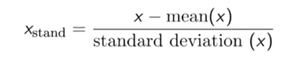

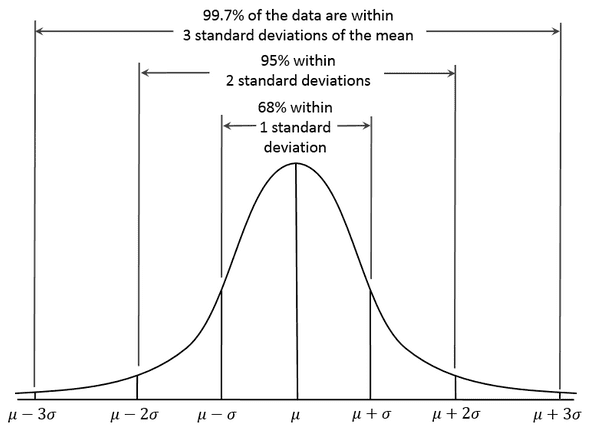

In [52]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 2.24121197,  0.3760568 ,  0.48686894, ..., -0.02617757,
         0.8461456 , -0.23877109],
       [-0.10946618,  0.3760568 ,  1.41293275, ..., -0.53352738,
        -0.49988559, -0.42200866],
       [-0.67776135, -0.60608439,  1.86449764, ..., -0.41953728,
        -0.51840526, -0.42200866],
       ...,
       [ 0.0570133 ,  0.3760568 ,  4.70332376, ..., -0.51012151,
        -1.18775564,  0.08548371],
       [-0.58836922,  0.3760568 ,  4.84655837, ..., -0.53591308,
        -1.21730909, -0.11986127],
       [-0.39190181,  0.3760568 ,  4.84655837, ..., -0.53591308,
        -1.21730909, -0.19508075]], shape=(11669, 11))

In [53]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(11669, 11)
             0         1         2         3         4         5         6   \
count 11669.000 11669.000 11669.000 11669.000 11669.000 11669.000 11669.000   
mean      0.000     0.000    -0.000     0.000    -0.000     0.000    -0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
min      -0.784    -3.553    -0.918    -0.647    -0.786    -0.741    -1.931   
25%      -0.475    -0.606    -0.918    -0.519    -0.542    -0.633    -0.853   
50%      -0.201     0.376    -0.263    -0.362    -0.364    -0.429    -0.138   
75%       0.200     0.376     0.539     0.002     0.030     0.161     0.834   
max      22.630     1.358     4.847     4.255     4.207     3.235     1.503   

             7         8         9         10  
count 11669.000 11669.000 11669.000 11669.000  
mean      0.000    -0.000    -0.000    -0.000  
std       1.000     1.000     1.000     1.000  
min      -1.275    -0.536    -3.246    -0.422  
25%      -0.748    -0.508    -0.523 

In [54]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0        55
1        55
2        55
3        60
4        60
         ..
11664    60
11665    60
11666    60
11667    60
11668    60
Name: noise_day, Length: 11669, dtype: int64


In [55]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [56]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(9335, 11)
(9335,)
(2334, 11)
(2334,)


Train model

In [57]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

score_linear = model.score(X_test, y_test)


0.3881669572014329
0.38760782272463157


In [58]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [ 0.11170405 -1.68398037 -1.30611048  0.99407954 -0.44922434  0.07065725
  0.90445897  0.31938179  0.53084018  2.08335599 -0.7534884 ] intercetp 59.66472026476803


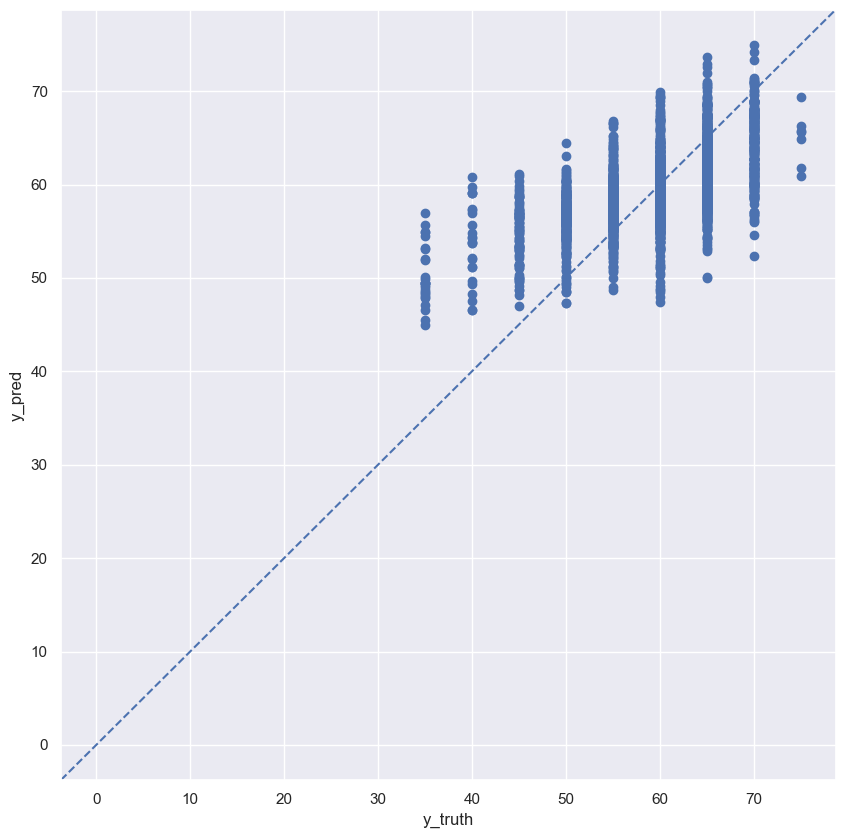

In [59]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_linear'] = y_test - y_pred
data_test['noise_pred_linear'] = y_pred
plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [60]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 2334 entries, 11292 to 5651
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   road_id            2334 non-null   str    
 1   noise_day          2334 non-null   int64  
 2   noise_evening      2334 non-null   int64  
 3   noise_night        2334 non-null   int64  
 4   road_length        2334 non-null   float64
 5   road_category      2334 non-null   int64  
 6   dist_to_main       2334 non-null   float64
 7   signals            2334 non-null   float64
 8   transport          2334 non-null   float64
 9   pois               2334 non-null   float64
 10  width              2334 non-null   float64
 11  height             2334 non-null   float64
 12  betw_centrality    2334 non-null   float64
 13  clos_centrality    2334 non-null   float64
 14  green_100          2334 non-null   float64
 15  diff_linear        2334 non-null   float64
 16  noise_pred_linear  2334 non-null   f

In [61]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main', 'signals']
).interactive()

alt.Chart(...)

## XGBoost

Let's try a different model class

In [62]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))
score_xgb = model.score(X_test, y_test)
data_test['score_xgb'] = score_xgb

0.8808356523513794
0.5755499601364136


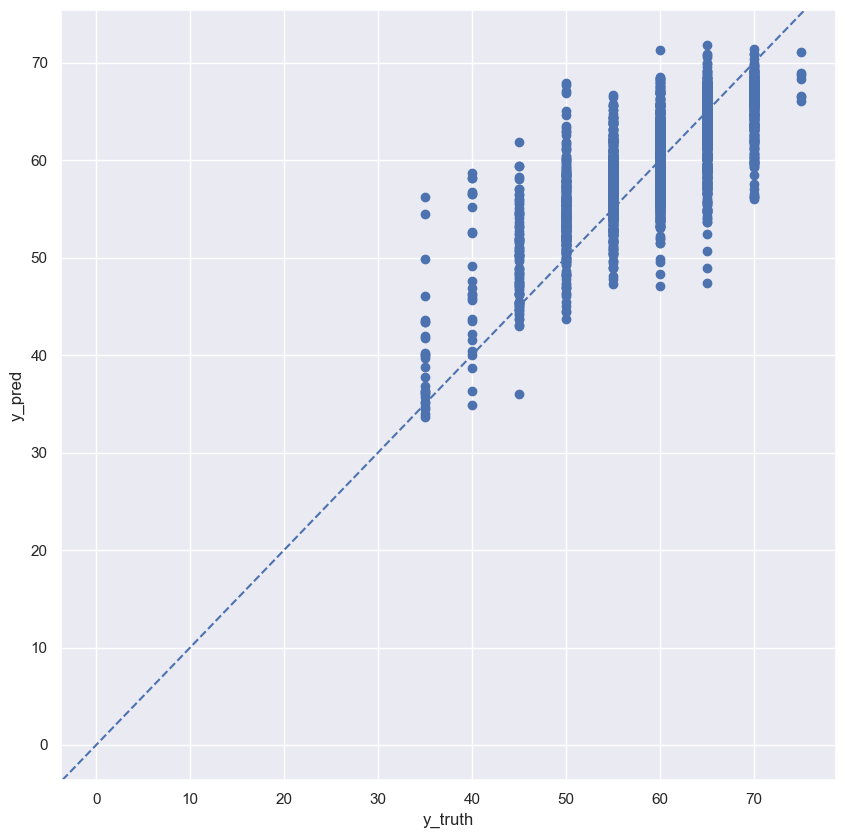

In [63]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_xgb'] = y_test - y_pred
data_test['noise_pred_xgb'] = y_pred

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [64]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main','signals']
).interactive()

alt.Chart(...)

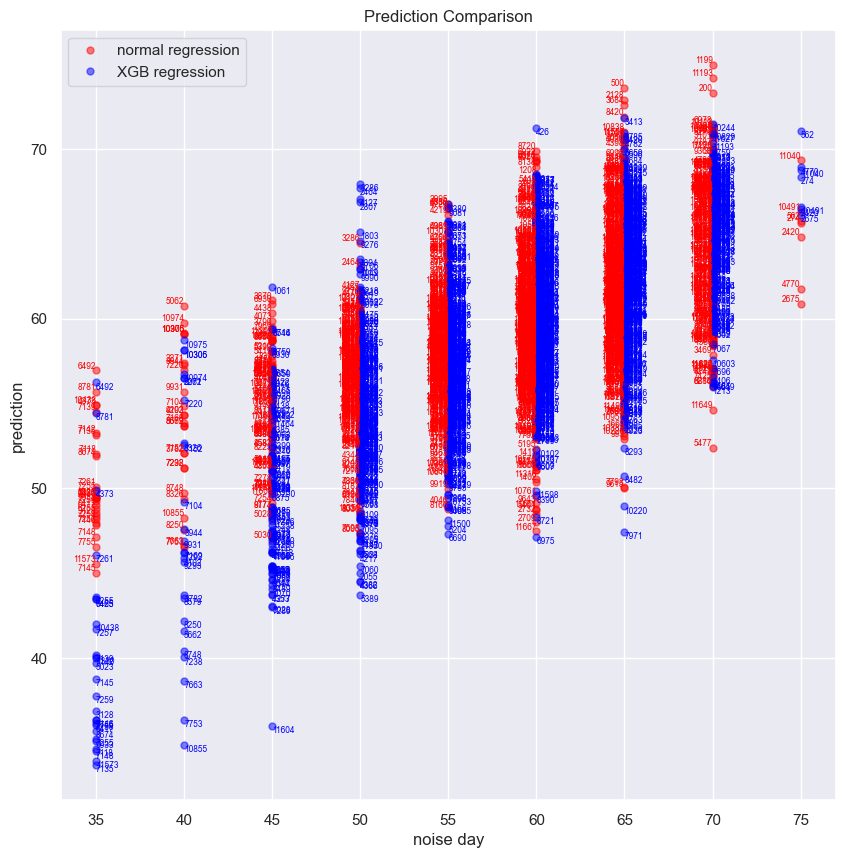

In [65]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()

In [66]:
data_test.shape

(2334, 22)

In [67]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

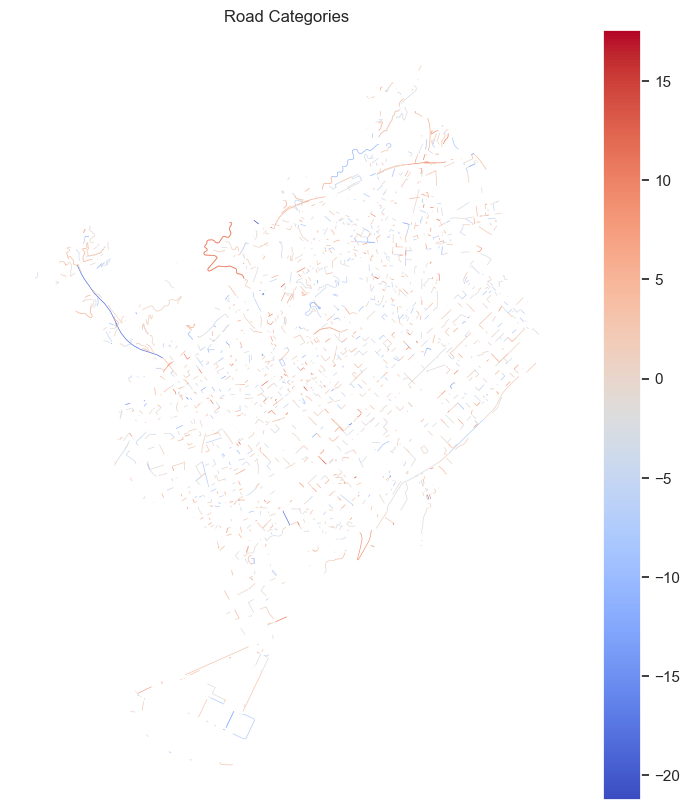

In [68]:
# Plot Road Categories
ax = merged_gdf.plot(column='diff_xgb', cmap='coolwarm', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [69]:
df_sorted = merged_gdf.sort_values(by="diff_xgb")
df_sorted.head(10)

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,betw_centrality,clos_centrality,green_100,diff_linear,noise_pred_linear,noisePred_reg,score_xgb,diff_xgb,noise_pred_xgb,noisePred_xg
9864,1001441863,1933546307,0,182988211,residential,1,30,Carrer de l'Harmonia,False,True,...,0.001,0.000,24.140,-21.949,56.949,56.949,0.576,-21.240,56.240,56.240
13627,2943846078,2943846077,0,676348906,residential,NaN,30,Carrer del Mont d'Orsà,False,True,...,0.001,0.000,5.368,-20.671,55.671,55.671,0.576,-19.461,54.461,54.461
6442,417976918,417976269,0,35714266,residential,1,30,Plaça d'Olèrdola,True,False,...,0.000,0.000,0.000,-19.134,59.134,59.134,0.576,-18.714,58.714,58.714
15097,5952574456,3951678282,0,630370997,residential,NaN,30,Carrer de Joan Orpí,False,True,...,0.000,0.000,0.691,-19.122,59.122,59.122,0.576,-18.131,58.131,58.131
14165,3951678282,5952574456,0,630370997,residential,NaN,30,Carrer de Joan Orpí,False,False,...,0.000,0.000,0.691,-19.122,59.122,59.122,0.576,-18.131,58.131,58.131
4769,323190992,255620227,0,"[1395147168, 645744134, 1168893386, 120332972,...",trunk,"['3', '5', '2']",80,Túnel de Vallvidrera,False,"[False, True]",...,0.000,0.000,42.003,-14.484,64.484,64.484,0.576,-17.954,67.954,67.954
16103,11009796687,71710025,0,"[770048769, 967901338, 1478859694, 899521073, ...",tertiary,2,30,Avinguda de la Reina Maria Cristina,True,False,...,0.002,0.000,6.361,-13.077,63.077,63.077,0.576,-17.710,67.710,67.710
15693,8412738278,8412738277,0,905914038,residential,NaN,30,Carrer de la Torre Dulac,True,False,...,0.000,0.000,24.168,-11.687,61.687,61.687,0.576,-17.061,67.061,67.061
1500,30294515,30313440,0,972011258,living_street,NaN,20,Carrer Major de Sarrià,True,False,...,0.005,0.000,0.000,-11.272,56.272,56.272,0.576,-16.880,61.880,61.880
16016,10182235280,3047640925,0,"[1112878641, 1112878652, 1112878653, 1240777463]",living_street,NaN,10,"['Carrer del Consell de Cent', 'Carrer de Pau ...",True,False,...,0.000,0.000,0.000,-10.994,60.994,60.994,0.576,-16.856,66.856,66.856
